# **RAG: Retrieval Augmented Generation**

### **What is RAG?**

RAG is the technique of grounding model's responses by letting them retrieve real time data from knowledge bases. It's used to make AI more personalized and reliable.


### **Why do we need RAG?**

> LLMs are frozen in time

they know nothing about your private documents or anything past their training cutoff. Retrieval-Augmented Generation (RAG) solves this by giving the model a reference knowledge to consult before answering.

In [1]:
!pip install -q qdrant-client sentence-transformers requests groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.9/389.9 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.7/139.7 kB 10.3 MB/s eta 0:00:00


### **Steps In RAG**

1. **Ingestion:** Preparing, embedding & storing the data

2. **Retrieval:** Finding relevant document to put in context

3. **Generation:** Prompting the llm with retrieved context to generate grounded response.

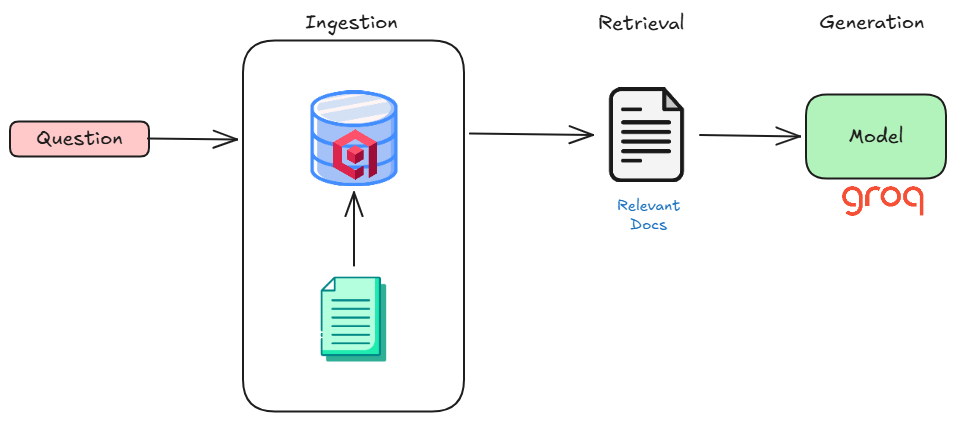

### **What are we going to build?**

An HR Policies Chatbot, that can answer about AtliqAI's HR Policies using RAG.


## **First Step: Ingestion**

Ingestion itself involves multiple steps:

- **Loading** the docuemnts into a readable format
- **Chunking**: Splitting them into smaller chunks
- **Embedding**: Creating their embeddings using the embedding models
- **Indexing**: Storing the embeddings and payloads on the vector DB

### **Loading**

The first step is loading the document so that we can process it.

In [2]:
# Loading the Document
import os
import requests

GITHUB_RAW_URL = "https://raw.githubusercontent.com/tnahddisttud/sample-doc/refs/heads/main/atliqai_hr_policies.txt"

def load_document(url: str) -> str:
    """Fetch a plain-text file from a raw GitHub URL."""
    response = requests.get(url, timeout=10)
    response.raise_for_status()
    return response.text

raw_text = load_document(GITHUB_RAW_URL)
print(f"Loaded {len(raw_text):,} characters")
print(raw_text[:400])  # Sanity check

Loaded 16,864 characters
# AtliqAI HR Policies

AtliqAI is committed to building a transparent, inclusive, and high-performance workplace. This document outlines the policies and guidelines that govern employment, conduct, compensation, and well-being at AtliqAI. All employees are expected to read, understand, and adhere to these policies from their first day of joining.

---

## Employment & Onboarding

### Offer and Joi


### **Chunking**
It's an essential preprocessing step where we break down large documents into smaller, manageable, and semantically meaningful text segments.

It optimizes RAG by ensuring retrieval accuracy, fitting content into LLM context windows, and reducing retrieval time.

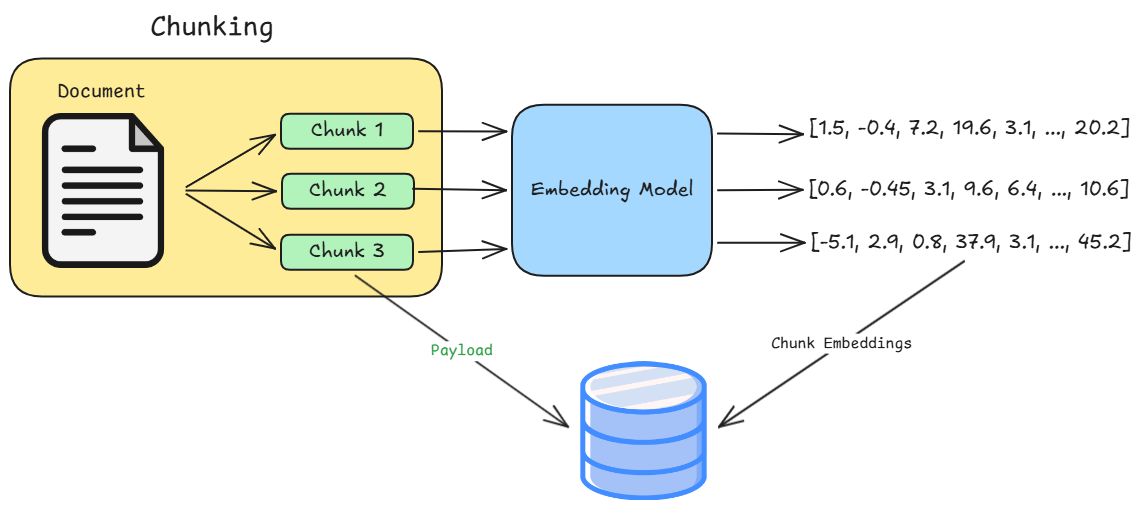





In [26]:
CHUNK_SIZE = 50

def parse_word_chunks(text: str, chunk_size: int = CHUNK_SIZE) -> list[dict]:
    # Strip markdown heading symbols and blank lines
    clean_lines = []
    for line in text.splitlines():
        line = line.strip().lstrip("#").strip()
        if line:
            clean_lines.append(line)

    # Join everything into one word list and slice
    words = " ".join(clean_lines).split()

    chunks = []
    for i in range(0, len(words), chunk_size):
        content = " ".join(words[i : i + chunk_size])
        chunks.append({
            "chunk_index": len(chunks),
            "content": content,
        })

    return chunks

In [27]:
chunks = parse_word_chunks(raw_text)
print(f"Total chunks: {len(chunks)}")

Total chunks: 51


In [5]:
# Inspect a chunk
for chunk in chunks[:3]:
    print("─" * 55)
    print(f"Content : {chunk['content'][:200]}…")

───────────────────────────────────────────────────────
Content : AtliqAI HR Policies AtliqAI is committed to building a transparent, inclusive, and high-performance workplace. This document outlines the policies and guidelines that govern employment, conduct, compe…
───────────────────────────────────────────────────────
Content : employment with a notice period of 15 days. Performance will be reviewed at the end of the 3rd and 6th month. Successful completion of probation leads to confirmation of employment, which will be comm…
───────────────────────────────────────────────────────
Content : internship policy and are not entitled to standard employee benefits unless explicitly mentioned. --- Working Hours & Attendance Standard Working Hours The standard workweek at AtliqAI is 40 hours, sp…


In [6]:
def build_chunk_text(chunk: dict) -> str:
    return chunk["content"]

### **Embedding**

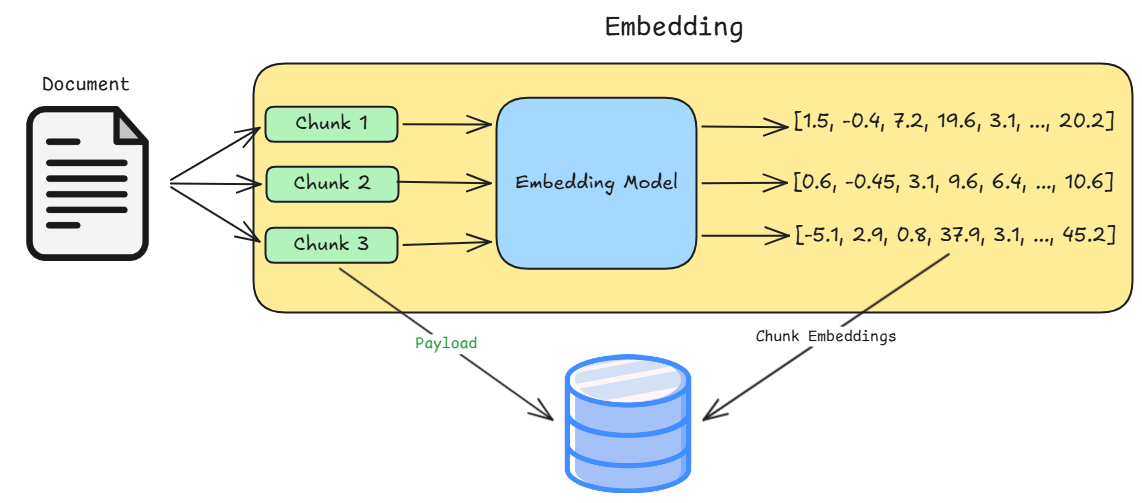

In [7]:
from sentence_transformers import SentenceTransformer

EMBEDDING_MODEL = "all-MiniLM-L6-v2"
embedder = SentenceTransformer(EMBEDDING_MODEL)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [8]:
# Extract Chunk Texts
chunk_texts = [build_chunk_text(c) for c in chunks]

print(f"Embedding {len(chunk_texts)} chunks …")
embeddings = embedder.encode(chunk_texts, show_progress_bar=True)

print(f"Shape: {embeddings.shape}")

Embedding 17 chunks …


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Shape: (17, 384)


### **Indexing**

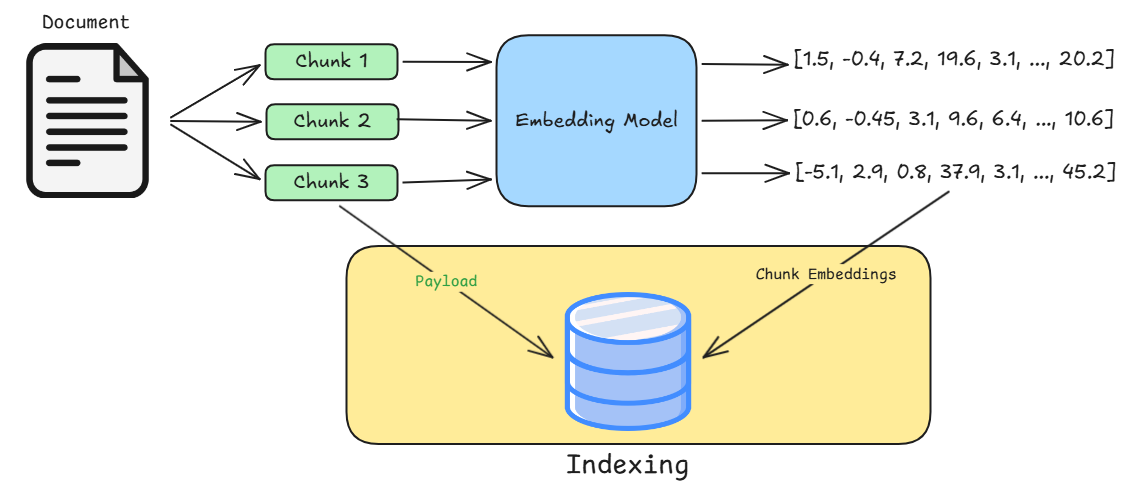

In [9]:
from qdrant_client import QdrantClient
from qdrant_client.models import (
    Distance, VectorParams, PointStruct,
    Filter, FieldCondition, MatchValue,
)

# "path" = no server needed for demos
# Production use: QdrantClient(url="http://localhost:6333")
client = QdrantClient(path="/tmp/langchain_qdrant")

COLLECTION_NAME = "docs"
DIM = embedder.get_sentence_embedding_dimension()

client.create_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=VectorParams(
        size=DIM,
        distance=Distance.COSINE,
    ),
)
print("Collection created.")

Collection created.


In [10]:
# Creating Points

points = [
    PointStruct(
        id=idx,
        vector=embedding.tolist(),
        payload={
            "content": chunk["content"],
        },
    )
    for idx, (chunk, embedding) in enumerate(zip(chunks, embeddings))
]

result = client.upsert(
    collection_name=COLLECTION_NAME,
    points=points,
    wait=True,   # Block until indexing completes before returning
)
print(f"Indexed {len(points)} points — status: {result.status}")

Indexed 17 points — status: completed


In [11]:
info = client.get_collection(COLLECTION_NAME)
print(f"Points     : {info.points_count}")
print(f"Dimensions : {info.config.params.vectors.size}")

Points     : 17
Dimensions : 384


## **Retrieval**

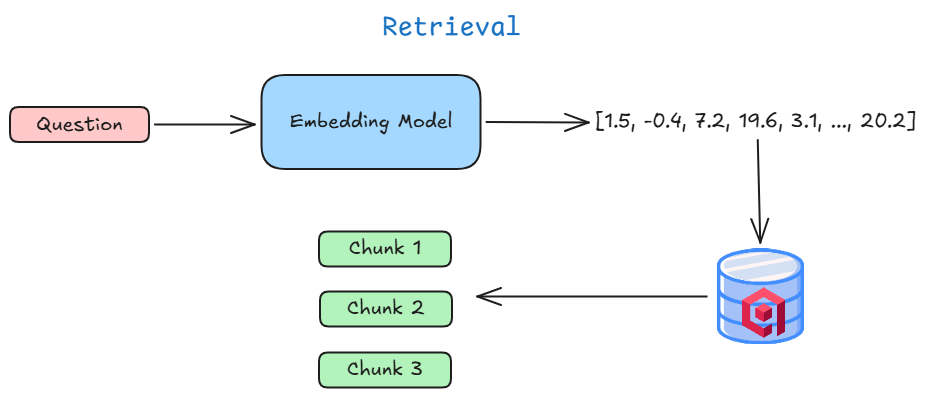

In [12]:
def retrieve(
    query: str,
    top_k: int = 5
) -> list[dict]:
    """
    Embed the query and return the top-k most similar chunks.

    Args:
        query          : User's question.
        top_k          : Number of chunks to return.
        section_filter : Optional H2 heading to restrict the search scope.
    """
    query_vector = embedder.encode(query).tolist()

    hits = client.query_points(
        collection_name=COLLECTION_NAME,
        query=query_vector,
        limit=top_k,
        with_payload=True,
    )

    return [{**hit.payload, "score": round(hit.score, 4)} for hit in hits.points]

In [13]:
results = retrieve("What is the leave policy", top_k=3)
for r in results:
    print(f"[score={r['score']}]")
    print(f"  {r['content'][:200]}…\n")

[score=0.4592]
  be carried forward to the next calendar year and lapse on December 31st. Sick Leave Employees are entitled to 10 sick leaves per calendar year. Sick leave can be availed in case of illness, hospitalis…

[score=0.4152]
  parents, and siblings. For extended family such as grandparents, in-laws, and first cousins, 2 days of bereavement leave are available. Additional unpaid leave may be requested subject to manager disc…

[score=0.4121]
  start of the workday and log out at the end. Failure to mark attendance for more than 3 consecutive days without prior intimation will be treated as absence without pay and may trigger an HR review. R…



## **RAG Pipeline**

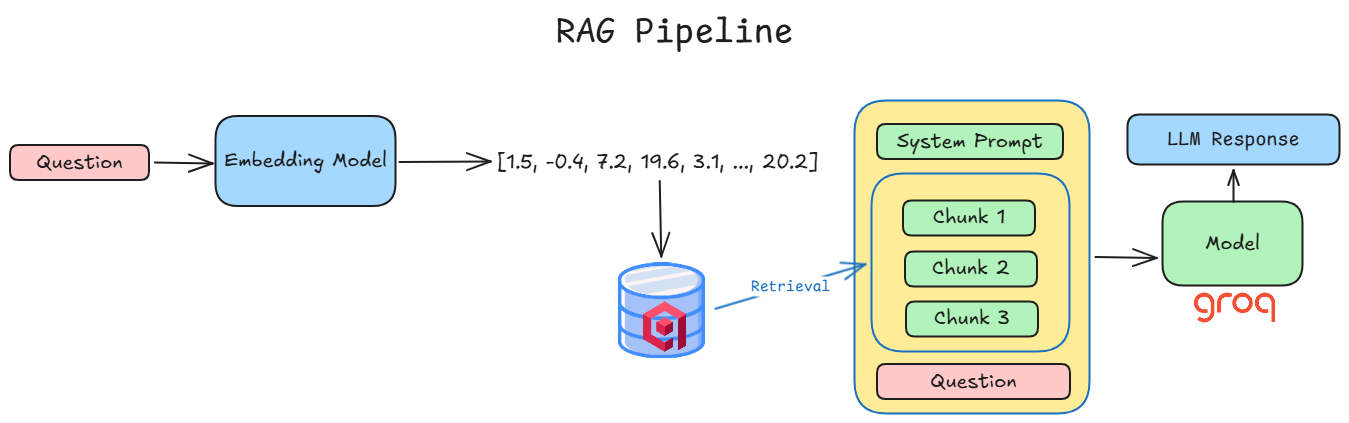

In [14]:
SYSTEM_PROMPT = """You are a helpful HR assistant.
Answer the user's question using ONLY the context provided below.
If the context does not contain enough information, say so — do not make things up.
Always cite the section name when referencing specific information."""

In [15]:
def build_context(retrieved_chunks: list[dict]) -> str:
    parts = []
    for i, chunk in enumerate(retrieved_chunks, 1):
        parts.append(f"[Source {i}]\n{chunk['content']}")
    return "\n\n---\n\n".join(parts)

## Setting up Groq for LLM Inference

**💡What is Groq?**

A platform that serves LLMs and provides access to OpenSource models in their freetier

---

**💡How to access models on Groq?**
 1. Visit : https://console.groq.com/keys
 2. Create an account using your email ID
 3. Click on the "Create API Key" button and enter a name for the key (we are using "CB_LangChain"
 4. Copy the generated key and paste it some where save
 5. Run the code below and paste the groq API Key in the text box

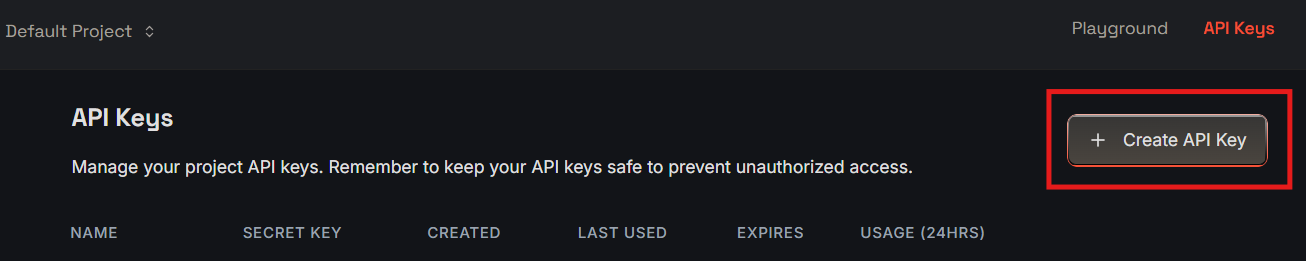

In [16]:
import getpass
import os

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

Enter your Groq API key: ··········


### **End-to-end RAG pipeline:**
  1. Retrieve relevant chunks from Qdrant
  2. Format them as a context block
  3. Send context + query to Groq and return the answer

In [22]:
from groq import Groq

groq_client = Groq()   # Reads GROQ_API_KEY from environment automatically
GROQ_MODEL  = "openai/gpt-oss-safeguard-20b"

def rag(query: str, top_k: int = 5):
    """
    End-to-end RAG pipeline:
      1. Retrieve relevant chunks from Qdrant
      2. Format them as a context block
      3. Send context + query to Groq and return the answer
    """
    # Step 1 — Retrieve
    chunks = retrieve(query, top_k=top_k)
    if not chunks:
        return "No relevant content found in the document."

    # Step 2 — Build context
    context = build_context(chunks)

    # Step 3 — Generate
    user_message = f"Context:\n{context}\n\nQuestion: {query}"

    response = groq_client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": user_message},
        ],
        temperature=0.2,   # Low = factual;  High = creative
    )
    return response.choices[0].message.content, context

In [25]:
answer, context = rag("What are the main topics covered in this document?")
print(answer)
print(f"{250*'='}")
print(f"\n\nSOURCES:\n {context}")

The document covers several key HR‑related areas, including:

1. **Grievance Management** – procedures for filing, timelines, and escalation (Source 1, “Grievance” section).  
2. **Data Privacy & Confidentiality** – handling of employee personal data and NDA obligations (Source 4, “Confidentiality Obligations” and “Data Breach Reporting”).  
3. **Employment & Onboarding** – offer acceptance, required documents, and joining formalities (Source 2, “Offer and Joining Formalities”).  
4. **Probation and Performance Review** – 6‑month probation, notice periods, and review schedule (Source 3, “Probation Period” and “Performance will be reviewed”).  
5. **Background Verification** – mandatory checks for new hires (Source 3, “Background Verification”).  
6. **Employment Types & Benefits** – distinctions between full‑time, part‑time, contractual, and intern roles (Source 3, “Employment Types”).  
7. **Internal Complaints Committee (POSH)** – handling of sexual‑harassment complaints and resoluti